In [19]:
#Mount Google Drive(Task1)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
#Load Dataset
path = "/content/drive/MyDrive/Housing.csv"

df = pd.read_csv(path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [22]:
#Display First 10 Rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [23]:
#Check Number of Rows and Columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [24]:
#View Column Names
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [25]:
#Identify Target and Features
target = "price"

features = [col for col in df.columns if col != target]

print("Target Variable:", target)
print("\nFeatures:")
print(features)

Target Variable: price

Features:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [26]:
#Check Missing Values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [27]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [28]:
#Task 2: Data Cleaning Remove Duplicate Rows
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [29]:
#Handle Missing Values
for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


/tmp/ipykernel_3441/1171091491.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3441/1171091491.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [30]:
#Check Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [31]:
#One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)

Original Shape: (545, 13)
Encoded Shape: (545, 14)


In [32]:
#View Encoded Data
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [33]:
#Task 3: Model Building Separate Features and Target
X = df_encoded.drop("price", axis=1)

y = df_encoded["price"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (545, 13)
Target Shape: (545,)


In [34]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 436
Testing Samples: 109


In [35]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [37]:
# Linear Regression Prediction
lr_pred = lr_model.predict(X_test)

In [38]:
#Evaluate Linear Regression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² :", lr_r2)

Linear Regression Results
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² : 0.6529242642153184


In [39]:
#Train Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained")

Random Forest Trained


In [40]:
#Random Forest Prediction
rf_pred = rf_model.predict(X_test)

In [41]:
#Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

Random Forest Results
MAE : 1013968.579587156
RMSE: 1398115.6668385956
R² : 0.6132752494107068


In [42]:
#Compare Models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


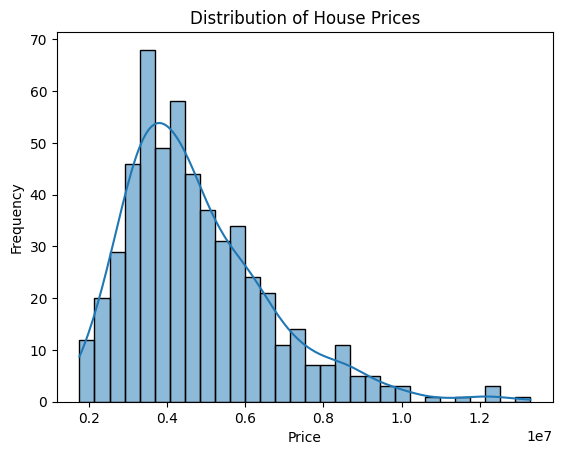

In [43]:
#Task 4: Visualizations Histogram of House Pricesplt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

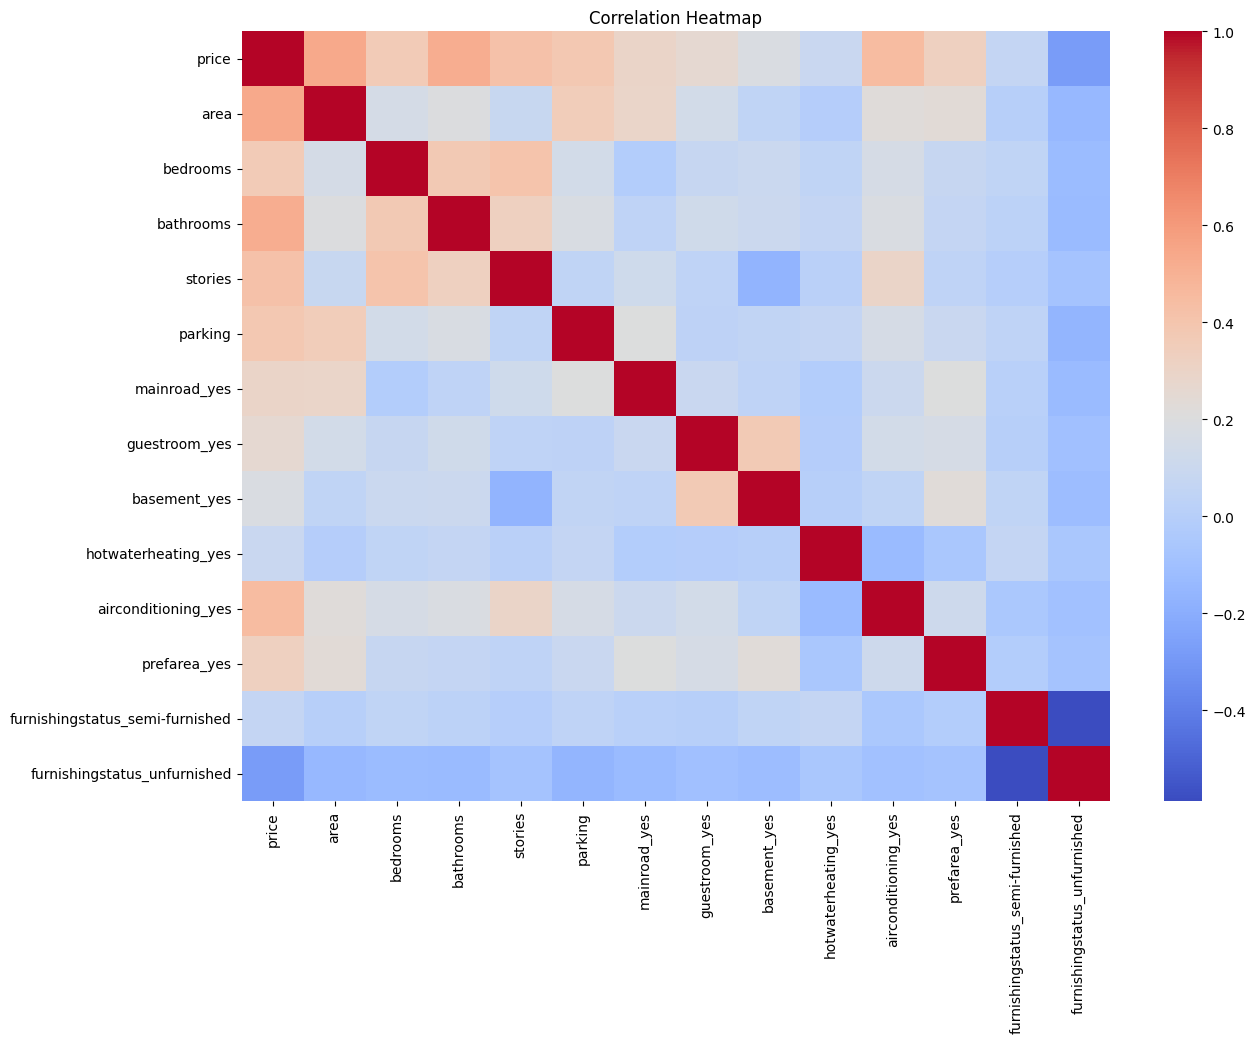

In [44]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

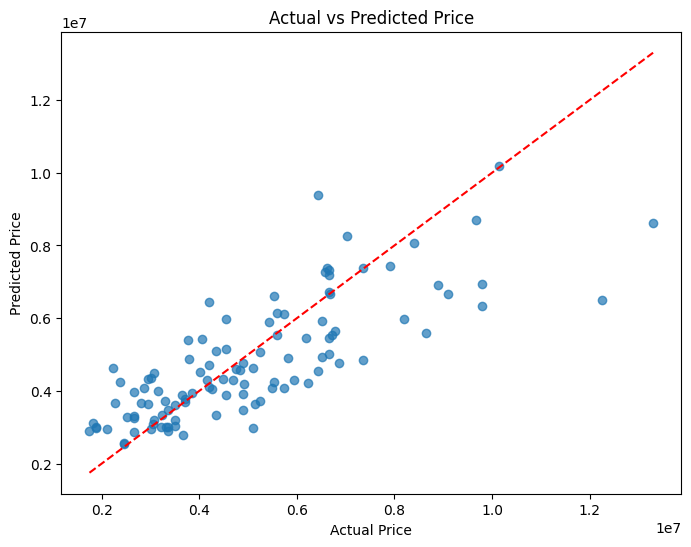

In [45]:
#Actual vs Predicted Price (Random Forest)
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [46]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


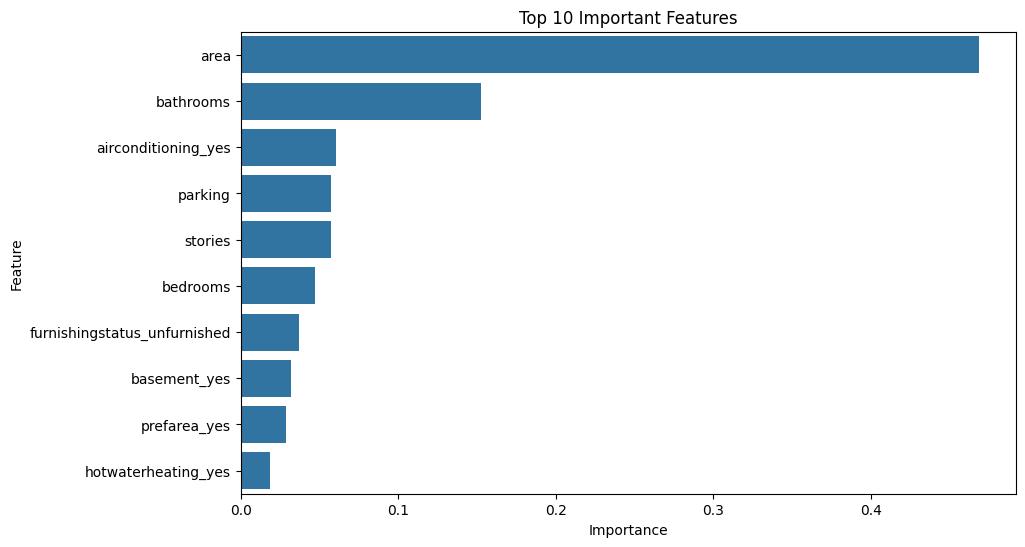

In [47]:
#Top 10 Important Features Chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

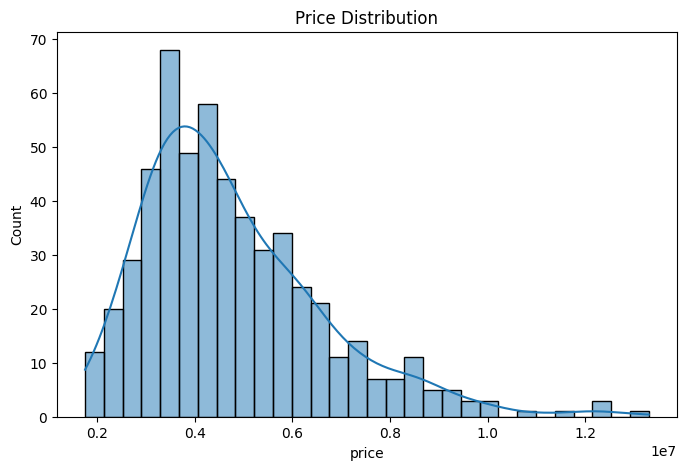

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

Improved Version

In [48]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

print("New Dataset Shape:", df.shape)

New Dataset Shape: (530, 13)


In [49]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

print("New Dataset Shape:", df.shape)

New Dataset Shape: (526, 13)


In [50]:
categorical_cols = df.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)

(526, 14)


In [51]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("===== LINEAR REGRESSION =====")
print("MAE =", lr_mae)
print("RMSE =", lr_rmse)
print("R² =", lr_r2)

===== LINEAR REGRESSION =====
MAE = 731740.3152788753
RMSE = 971860.4629055543
R² = 0.7181966415684482


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=1000, n_jobs=-1, random_state=42)

In [57]:
rf_pred = rf_model.predict(X_test)

In [58]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("===== RANDOM FOREST =====")
print("MAE =", rf_mae)
print("RMSE =", rf_rmse)
print("R² =", rf_r2)

===== RANDOM FOREST =====
MAE = 751320.1096696351
RMSE = 1024107.3915214271
R² = 0.687082871128049


In [59]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae, rf_mae],
    "RMSE":[lr_rmse, rf_rmse],
    "R2 Score":[lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,731740.315279,9.718605e+05,0.718197
1,Random Forest,751320.109670,1.024107e+06,0.687083


In [60]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

print("Gradient Boosting R² =",
      r2_score(y_test, gbr_pred))

Gradient Boosting R² = 0.668570830530048


In [61]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

print("===== GRADIENT BOOSTING =====")
print("MAE =", gbr_mae)
print("RMSE =", gbr_rmse)
print("R² =", gbr_r2)

===== GRADIENT BOOSTING =====
MAE = 790888.2067928226
RMSE = 1053965.0181127298
R² = 0.668570830530048


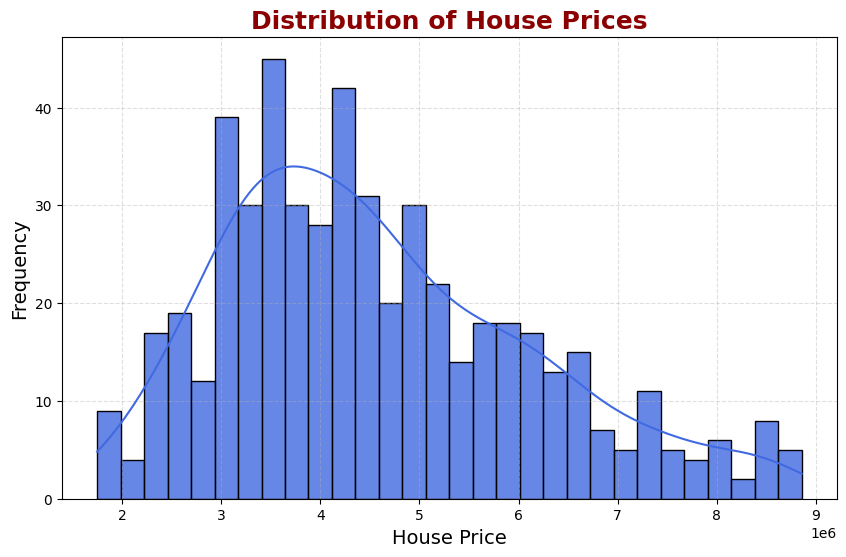

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black',
    alpha=0.8
)

plt.title(
    'Distribution of House Prices',
    fontsize=18,
    fontweight='bold',
    color='darkred'
)

plt.xlabel('House Price', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

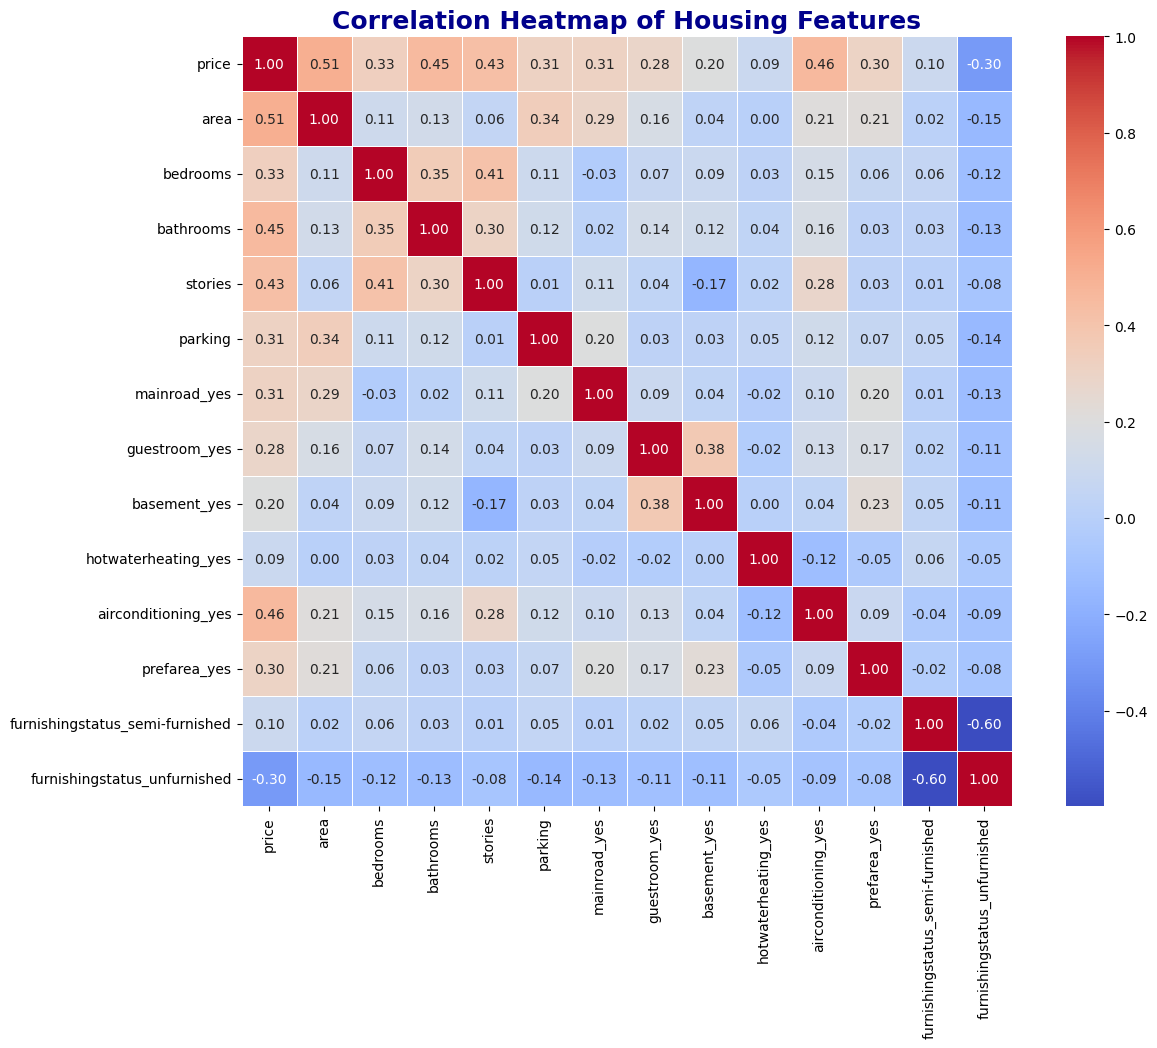

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Housing Features',
    fontsize=18,
    fontweight='bold',
    color='darkblue'
)

plt.show()

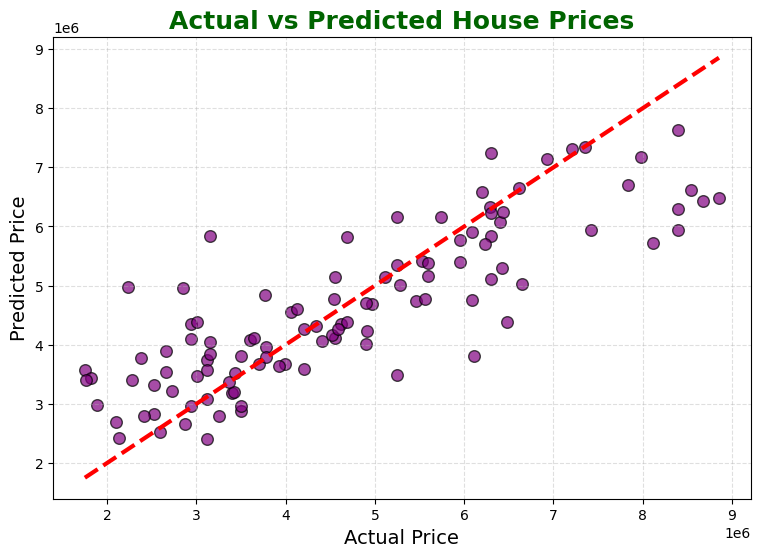

In [64]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_test,
    rf_pred,
    color='purple',
    edgecolors='black',
    alpha=0.7,
    s=70
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=3,
    linestyle='--'
)

plt.title(
    'Actual vs Predicted House Prices',
    fontsize=18,
    fontweight='bold',
    color='darkgreen'
)

plt.xlabel('Actual Price', fontsize=14)
plt.ylabel('Predicted Price', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

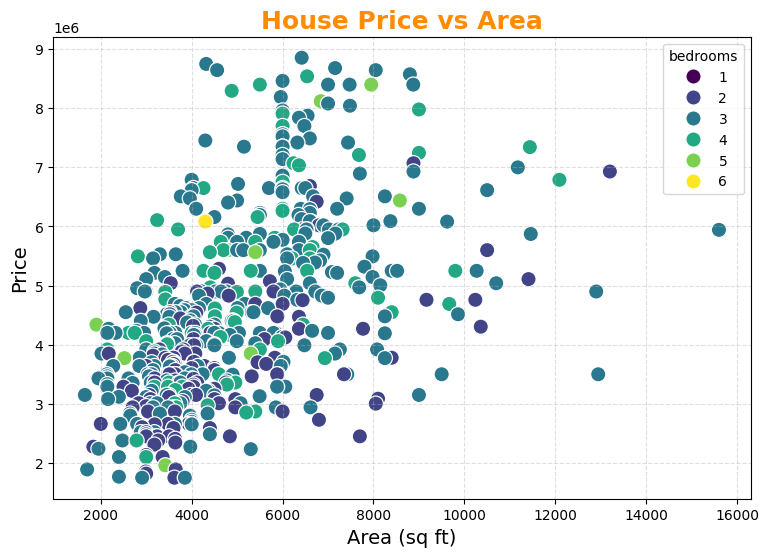

In [65]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='area',
    y='price',
    hue='bedrooms',
    palette='viridis',
    s=120
)

plt.title(
    'House Price vs Area',
    fontsize=18,
    fontweight='bold',
    color='darkorange'
)

plt.xlabel('Area (sq ft)', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

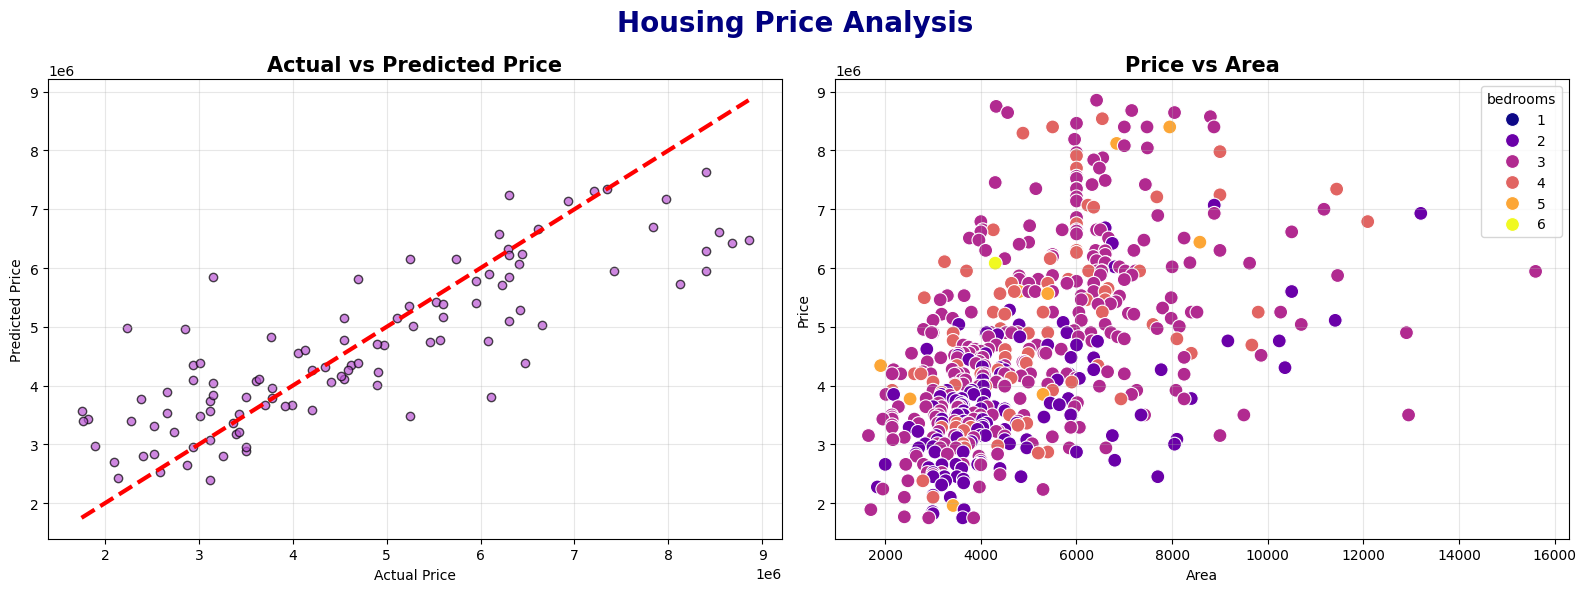

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Actual vs Predicted
axes[0].scatter(
    y_test,
    rf_pred,
    color='mediumorchid',
    edgecolors='black',
    alpha=0.7
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=3
)

axes[0].set_title(
    'Actual vs Predicted Price',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[0].grid(True, alpha=0.3)

# Price vs Area
sns.scatterplot(
    data=df,
    x='area',
    y='price',
    hue='bedrooms',
    palette='plasma',
    s=100,
    ax=axes[1]
)

axes[1].set_title(
    'Price vs Area',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Area')
axes[1].set_ylabel('Price')

axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Housing Price Analysis',
    fontsize=20,
    fontweight='bold',
    color='navy'
)

plt.tight_layout()

plt.show()

In [67]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="
    background: linear-gradient(135deg,#4facfe,#00f2fe);
    padding:25px;
    border-radius:15px;
    color:white;
    font-family:Arial;
    box-shadow:0px 4px 15px rgba(0,0,0,0.3);
">

<h1 style="text-align:center;">
🏠 Housing Price Prediction Results
</h1>

<hr style="border:2px solid white;">

<h2>📊 Linear Regression</h2>

<ul style="font-size:18px;">
<li><b>MAE:</b> {lr_mae:,.2f}</li>
<li><b>RMSE:</b> {lr_rmse:,.2f}</li>
<li><b>R² Score:</b> {lr_r2:.4f}</li>
<li><b>Accuracy Equivalent:</b> {lr_r2*100:.2f}%</li>
</ul>

<hr style="border:1px solid white;">

<h2>🌲 Random Forest Regressor</h2>

<ul style="font-size:18px;">
<li><b>MAE:</b> {rf_mae:,.2f}</li>
<li><b>RMSE:</b> {rf_rmse:,.2f}</li>
<li><b>R² Score:</b> {rf_r2:.4f}</li>
<li><b>Accuracy Equivalent:</b> {rf_r2*100:.2f}%</li>
</ul>

<hr style="border:2px solid white;">

<h2 style="text-align:center;">
🏆 Best Model:
{"Linear Regression" if lr_r2 > rf_r2 else "Random Forest"}
</h2>

</div>
"""))

**Task 5 — Insights & Summary**
Q1. Which features influence house price the most?

The features that influence house price the most are area, bathrooms, parking spaces, air conditioning, and the number of stories. Among these, the area of the house has the strongest impact on the selling price. Houses with larger areas and better amenities generally have higher prices.

Q2. How accurate was your model (in plain terms)?

The Linear Regression model achieved an R² score of 0.718, which means it explained about 71.8% of the variation in house prices. In simple terms, the model was able to predict house prices reasonably well and provided reliable estimates based on the available features.

Q3. What surprised you in the data?

A surprising finding was that house area had a much stronger effect on price than the number of bedrooms. Even houses with fewer bedrooms could have high prices if they had a large area and additional amenities such as air conditioning or a preferred location.

Q4. One recommendation for a real estate business based on your findings.

Real estate businesses should focus on larger properties with modern amenities such as air conditioning, parking facilities, and good locations, as these factors significantly increase property value and attract more buyers. Such properties are likely to generate higher profits and customer interest.